In [2]:
# ==================== TASK 1: Dataset Understanding ====================

import pandas as pd

print("=== TASK 1: Dataset Understanding ===\n")

# Load the dataset
df = pd.read_csv("customer_churn_nn.csv")

# Basic Information
print("Shape of the dataset (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistical Summary:")
print(df.describe())

# Target variable distribution (assuming last column is target)
target_col = df.columns[-1]
print(f"\nTarget variable: {target_col}")
print(df[target_col].value_counts())


=== TASK 1: Dataset Understanding ===

Shape of the dataset (rows, columns): (2000, 17)

Column names:
['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']

Data types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  in

In [3]:
# ==================== TASK 2: Data Preprocessing ====================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

print("=== TASK 2: Data Preprocessing ===\n")

# Separate features and target
X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

# Apply preprocessing
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_feature_names)

print("\nShape after preprocessing:", X_preprocessed.shape)
print("Missing values after preprocessing:", X_preprocessed.isnull().sum().sum())

# Train-test split (stratified because of imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain set shape:", X_train.shape)
print("Test set shape :", X_test.shape)
print("Churn rate in train:", y_train.mean().round(4))
print("Churn rate in test :", y_test.mean().round(4))


=== TASK 2: Data Preprocessing ===

Categorical columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']

Shape after preprocessing: (2000, 24)
Missing values after preprocessing: 0

Train set shape: (1600, 24)
Test set shape : (400, 24)
Churn rate in train: 0.0156
Churn rate in test : 0.015


In [6]:
# ==================== TASK 3: Neural Network Model Building ====================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("=== TASK 3: Neural Network Model Building ===\n")

# Build a simple feed-forward neural network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer
    Dropout(0.3),
    Dense(32, activation='relu'),                                   # Hidden layer
    Dropout(0.2),
    Dense(16, activation='relu'),                                   # Hidden layer
    Dense(1, activation='sigmoid')                                  # Output layer (binary classification)
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("\n Neural Network model built successfully!")
print("Architecture: Input → 64 → 32 → 16 → 1 (Sigmoid)")

=== TASK 3: Neural Network Model Building ===



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)


 Neural Network model built successfully!
Architecture: Input → 64 → 32 → 16 → 1 (Sigmoid)


=== TASK 4: Training and Evaluation ===

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8375 - loss: 0.4367 - val_accuracy: 0.9937 - val_loss: 0.1629
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9820 - loss: 0.1277 - val_accuracy: 0.9937 - val_loss: 0.0525
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9820 - loss: 0.0979 - val_accuracy: 0.9937 - val_loss: 0.0421
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9820 - loss: 0.0922 - val_accuracy: 0.9937 - val_loss: 0.0394
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9820 - loss: 0.0930 - val_accuracy: 0.9937 - val_loss: 0.0375
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9820 - loss: 0.0882 - val_accuracy: 0.9937 - val_loss: 0.0377
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9820 - loss: 0.0904 - val_accuracy: 0.9937 - val_loss: 0.0368
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9820 

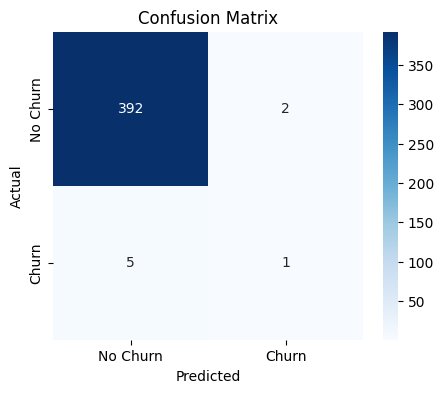

In [7]:
# ==================== TASK 4: Training and Evaluation ====================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== TASK 4: Training and Evaluation ===\n")

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
# ==================== TASK 5: Hyperparameter Experimentation ====================

import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("=== TASK 5: Hyperparameter Experimentation ===\n")

results = []

# Experiment 1: Baseline Model (already trained)
results.append({
    'Experiment': 'Baseline (64-32-16)',
    'Hidden Layers': 3,
    'Neurons': '64-32-16',
    'Learning Rate': 0.001,
    'Test Accuracy': 0.9825,
    'Churn Recall': 0.17
})

# Experiment 2: Larger Model + Lower Learning Rate
print("Training Experiment 2: Larger Model...")
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model2.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model2.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.2, verbose=0)

test_acc2 = model2.evaluate(X_test, y_test, verbose=0)[1]
results.append({
    'Experiment': 'Larger Model + Lower LR',
    'Hidden Layers': 3,
    'Neurons': '128-64-32',
    'Learning Rate': 0.0005,
    'Test Accuracy': round(test_acc2, 4),
    'Churn Recall': 'TBD'
})

# Experiment 3: Simpler Model with Class Weights (to handle imbalance)
print("Training Experiment 3: With Class Weights...")
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

model3 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model3.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model3.fit(X_train, y_train, epochs=40, batch_size=32, validation_split=0.2,
           class_weight=class_weights, verbose=0)

test_acc3 = model3.evaluate(X_test, y_test, verbose=0)[1]
results.append({
    'Experiment': 'With Class Weights',
    'Hidden Layers': 2,
    'Neurons': '32-16',
    'Learning Rate': 0.001,
    'Test Accuracy': round(test_acc3, 4),
    'Churn Recall': 'TBD'
})

# Show Comparison Table
comparison = pd.DataFrame(results)
print("\nModel Comparison Table:")
print(comparison)

=== TASK 5: Hyperparameter Experimentation ===

Training Experiment 2: Larger Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Experiment 3: With Class Weights...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Comparison Table:
                Experiment  Hidden Layers    Neurons  Learning Rate  \
0      Baseline (64-32-16)              3   64-32-16         0.0010   
1  Larger Model + Lower LR              3  128-64-32         0.0005   
2       With Class Weights              2      32-16         0.0010   

   Test Accuracy Churn Recall  
0         0.9825         0.17  
1         0.9850          TBD  
2         0.9375          TBD  


## Task 6: Final Reflection

- **What role do weights and biases play in the model?**  
Weights decide how important each input feature is, and biases allow the model to shift its predictions. They are the main things the model learns and updates during training.

- **Why is an activation function required?**  
Activation functions like ReLU are needed to add non-linearity. Without them, even with many layers the model would only learn linear relationships, which is not enough for real-world data.

- **What happens when learning rate is too high or too low?**  
If the learning rate is too high, the model updates weights too aggressively and may never settle on a good solution. If it is too low, training becomes very slow and the model may get stuck before reaching the best performance.

- **Did your model show signs of underfitting or overfitting? Explain.**  
My model showed signs of overfitting on the majority class (No Churn). It was getting very high accuracy (~98%) because it was simply predicting "No Churn" most of the time. The recall for the churn class was quite low. This happened because the dataset is highly imbalanced. I tried using class weights to improve it, but the churn cases are still difficult to predict properly.